# Fine-tuning LaMa + A-ESRGAN para Restauración de Fotografía Vintage

Pipeline de re-entrenamiento supervisado de dos etapas:
1. Fine-tuning de **LaMa** (inpainting) sobre pares degradado/GT del dataset vintage sintético.
2. Fine-tuning de **A-ESRGAN** (super-resolución x4) sobre pares LR/HR generados desde imágenes limpias.
3. Evaluación cuantitativa (PSNR, SSIM, LPIPS) comparando modelos pre-entrenados vs fine-tuneados.

> **Requisito:** Ejecutar en Google Colab con GPU (T4 o superior). Runtime → Change runtime type → T4 GPU.

## 0. Setup: Instalación y Configuración

Instala las dependencias necesarias para todo el pipeline. Reinicia el runtime si Colab ya había cargado versiones anteriores de PIL/numpy antes de ejecutar esta celda.

In [1]:
# Celda 1: Dependencias base
%pip install -q \
    kagglehub \
    simple-lama-inpainting \
    opencv-python \
    matplotlib \
    numpy \
    tqdm \
    scikit-image \
    pandas \
    lpips \
    omegaconf \
    hydra-core \
    "basicsr>=1.3.3.11" \
    "facexlib>=0.2.0.3" \
    "gfpgan>=0.2.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 12.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 17.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Celda 2: Pin de versiones críticas para evitar bug numpy._core durante la sesión
#
# Cuando varios pip installs ocurren durante la sesión (LaMa requirements, basicsr,
# pytorch-msssim, etc.) pueden mezclar archivos de distintas versiones de numpy y
# romper imports con:
#     ImportError: cannot import name '_center' from 'numpy._core.umath'
#
# Aquí forzamos un set internamente consistente con --force-reinstall y dejamos un
# PIP_CONSTRAINT para que los installs posteriores no degraden el pin.

import subprocess, sys, os
from pathlib import Path

PINS = [
    'numpy==2.0.2',           # último parche estable de la rama 2.0 (compatible con scipy 1.14, skimage 0.24)
    'scipy==1.14.1',          # última 1.14 → exige numpy >= 2.0, < 2.2
    'scikit-image==0.24.0',   # última 0.24 → compatible con numpy 2.0
]

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '--force-reinstall', *PINS],
    check=True,
)

# Constraint file: pip lo respetará en las celdas siguientes (no upgrade implícito)
_CONSTRAINT = Path('/content/numpy_pins.txt')
_CONSTRAINT.write_text('\n'.join(PINS))
os.environ['PIP_CONSTRAINT'] = str(_CONSTRAINT)

print('Pin aplicado:', PINS)
print('PIP_CONSTRAINT activo →', os.environ['PIP_CONSTRAINT'])


Pin aplicado: ['numpy==2.0.2', 'scipy==1.14.1', 'scikit-image==0.24.0']
PIP_CONSTRAINT activo → /content/numpy_pins.txt


In [3]:
# Celda 3: Imports y configuración global
%matplotlib inline

import os, sys, site, shutil, subprocess
from pathlib import Path
from typing import Optional, Sequence
import cv2
import numpy as np
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
import torch
from IPython.display import display

ImageFile.LOAD_TRUNCATED_IMAGES = True

try:
    from google.colab import output
    IN_COLAB = True
except Exception:
    IN_COLAB = False

WORK_DIR = Path('/content/finetune_work')
WORK_DIR.mkdir(parents=True, exist_ok=True)

LAMA_REPO_DIR = Path('/content/lama')
AESRGAN_REPO_DIR = Path('/content/A-ESRGAN')

# Directorios de datos
LAMA_TRAIN_DIR  = WORK_DIR / 'data' / 'lama_train'
LAMA_VAL_DIR    = WORK_DIR / 'data' / 'lama_val'
SR_TRAIN_DIR    = WORK_DIR / 'data' / 'aesrgan_train'
SR_VAL_DIR      = WORK_DIR / 'data' / 'aesrgan_val'

# Directorios de LaMa ya provienen de Drive (Fase 2); aqui solo A-ESRGAN.
for d in [SR_TRAIN_DIR/'HR',       SR_TRAIN_DIR/'LR',
          SR_VAL_DIR/'HR',         SR_VAL_DIR/'LR',
          WORK_DIR/'checkpoints'/'lama_finetuned',
          WORK_DIR/'checkpoints'/'aesrgan_finetuned',
          WORK_DIR/'results']:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'GPU disponible: {torch.cuda.is_available()}')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

GPU disponible: True
Device: cuda
PyTorch: 2.11.0+cu128


In [ ]:
# Dataset de LaMa: generado en Fase 1 y guardado en Google Drive.
from google.colab import drive
drive.mount('/content/drive')

import sys
from pathlib import Path
PROJECT_DIR = Path('/content/drive/MyDrive/TFM')
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

LAMA_DATA      = PROJECT_DIR / 'data' / 'lama_synthetic'
LAMA_TRAIN_DIR = LAMA_DATA / 'train'
LAMA_VAL_DIR   = LAMA_DATA / 'val'
LAMA_TEST_DIR  = LAMA_DATA / 'test'
assert LAMA_TRAIN_DIR.exists(), f"Falta el dataset en {LAMA_DATA}. Genera en Fase 1 con SAVE_TO_DISK=True."
print("Dataset LaMa:", {s: len(list((LAMA_DATA / s / 'images').glob('*.png'))) for s in ('train','val','test')})

In [4]:
# Celda 4: Parche Pillow 11.x — añadir setter a JpegImageFile.mode
# Motivo: el JpegImagePlugin asigna self.mode='RGB' en SOF(), pero en
# Pillow 11.x mode es @property sin setter → AttributeError al abrir JPEGs.
# La extensión C (_imaging.so) no se puede descargar; hay que restaurar 11.3.0 y parchear.
import subprocess, sys

# Restaurar Python-files de Pillow 11.3.0 (deben coincidir con la C-extension en memoria)
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '--force-reinstall', 'Pillow==11.3.0'],
    check=True
)

# Limpiar caché de módulos PIL (C-extension se reusa desde memoria, Python-files se recargan)
for mod_name in [k for k in list(sys.modules.keys()) if k.lower().startswith('pil')]:
    del sys.modules[mod_name]

# Reimportar PIL desde disco (Python-files 11.3.0 + C-extension 11.3.0 en memoria)
import PIL
from PIL import Image, ImageFile
import PIL.JpegImagePlugin
ImageFile.LOAD_TRUNCATED_IMAGES = True
print(f"Pillow restaurado: {PIL.__version__}")

# Parchear la propiedad mode read-only en JpegImageFile
# En PIL 11.x, mode pasó a ser @property sin setter, pero el plugin JPEG
# aún hace self.mode = "RGB" en el handler SOF → AttributeError
_patched = False
for cls in PIL.JpegImagePlugin.JpegImageFile.__mro__:
    if 'mode' in cls.__dict__:
        prop = cls.__dict__['mode']
        if isinstance(prop, property) and prop.fset is None:
            def _mode_setter(self, value):
                object.__setattr__(self, '_mode', value)
            cls.mode = prop.setter(_mode_setter)
            print(f"✓ Setter añadido a {cls.__name__}.mode")
            _patched = True
        elif isinstance(prop, property):
            print(f"✓ {cls.__name__}.mode ya tiene setter — sin parche")
        else:
            print(f"✓ {cls.__name__}.mode es atributo normal — sin parche")
        break

# Test JPEG round-trip
import io
_t = Image.new('RGB', (16, 16), (200, 100, 50))
_buf = io.BytesIO(); _t.save(_buf, 'JPEG'); _buf.seek(0)
_loaded = Image.open(_buf).convert('RGB')
assert _loaded.size == (16, 16), "JPEG round-trip falló"
print(f"✓ JPEG open/convert OK — size={_loaded.size}, mode={_loaded.mode}")

Pillow restaurado: 11.3.0
✓ Setter añadido a Image.mode
✓ JPEG open/convert OK — size=(16, 16), mode=RGB


## 1. Descarga de Datasets

Se descargan los dos datasets del dominio vintage:

- **`marcinrutecki/old-photos`**: fotos antiguas reales (sin GT pareado; solo para validación visual).
- **`shrutimandaokar2301/vintage-degraded-image-synthetic-real`**: dataset con split limpio/degradado pareado.
  - `01_Clean_Candidates_GT/` — imágenes limpias de referencia (GT)
  - `02_Damaged_Testing_Set/` — imágenes dañadas reales
  - `03_Synthetic_Dataset/Train_Input_Degraded/` — imágenes degradadas sintéticas (pareadas con GT por token `imgNN`)

In [5]:
# Celda 5: Descarga datasets
import kagglehub

old_photos_path    = Path(kagglehub.dataset_download('marcinrutecki/old-photos'))
vintage_path       = Path(kagglehub.dataset_download(
    'shrutimandaokar2301/vintage-degraded-image-synthetic-real'))

CLEAN_GT_DIR       = vintage_path / '01_Clean_Candidates_GT'
DAMAGED_REAL_DIR   = vintage_path / '02_Damaged_Testing_Set'
SYNTH_DEGRADED_DIR = vintage_path / '03_Synthetic_Dataset' / 'Train_Input_Degraded'

for name, path in [
    ('Old Photos',         old_photos_path),
    ('Clean GT',           CLEAN_GT_DIR),
    ('Damaged Real',       DAMAGED_REAL_DIR),
    ('Synth Degraded',     SYNTH_DEGRADED_DIR),
]:
    files = sorted(p for p in path.rglob('*')
                   if p.suffix.lower() in {'.png','.jpg','.jpeg'})
    print(f'{name:20s}: {len(files):4d} imágenes')

100%|██████████| 2.45M/2.45M [00:00<00:00, 59.5MB/s]

Extracting files...


100%|██████████| 84.3M/84.3M [00:00<00:00, 146MB/s]

Extracting files...


Old Photos          :   29 imágenes
Clean GT            :  146 imágenes
Damaged Real        :   54 imágenes
Synth Degraded      :  438 imágenes


### 1.1 Emparejamiento degradado → GT limpio

Las imágenes sintéticas del split `03_Synthetic_Dataset` incluyen un token `imgNN` en el nombre de fichero que permite emparejarlas con su GT limpio en `01_Clean_Candidates_GT`. La función `build_pairs()` extrae estos pares.

In [6]:
# Celda 6: Construir mapa de pares degradado -> GT limpio
import re

def extract_img_id(path: Path) -> Optional[str]:
    """Extrae el token imgNN del nombre de fichero."""
    m = re.search(r'img\d+', path.stem.lower())
    return m.group(0) if m else None

def build_pairs(degraded_dir: Path, clean_dir: Path) -> list[dict]:
    """Empareja imágenes degradadas con su GT limpio por token imgNN."""
    clean_files = sorted(p for p in clean_dir.rglob('*')
                         if p.suffix.lower() in {'.png','.jpg','.jpeg'})
    clean_by_id = {extract_img_id(p): p for p in clean_files if extract_img_id(p)}

    pairs = []
    for deg_path in sorted(p for p in degraded_dir.rglob('*')
                            if p.suffix.lower() in {'.png','.jpg','.jpeg'}):
        img_id = extract_img_id(deg_path)
        if img_id and img_id in clean_by_id:
            pairs.append({'degraded': deg_path, 'clean': clean_by_id[img_id]})

    return pairs

SYNTH_PAIRS = build_pairs(SYNTH_DEGRADED_DIR, CLEAN_GT_DIR)
print(f'Pares sintéticos disponibles: {len(SYNTH_PAIRS)}')
assert len(SYNTH_PAIRS) > 0, 'No se encontraron pares. Revisar estructura del dataset.'

Pares sintéticos disponibles: 438


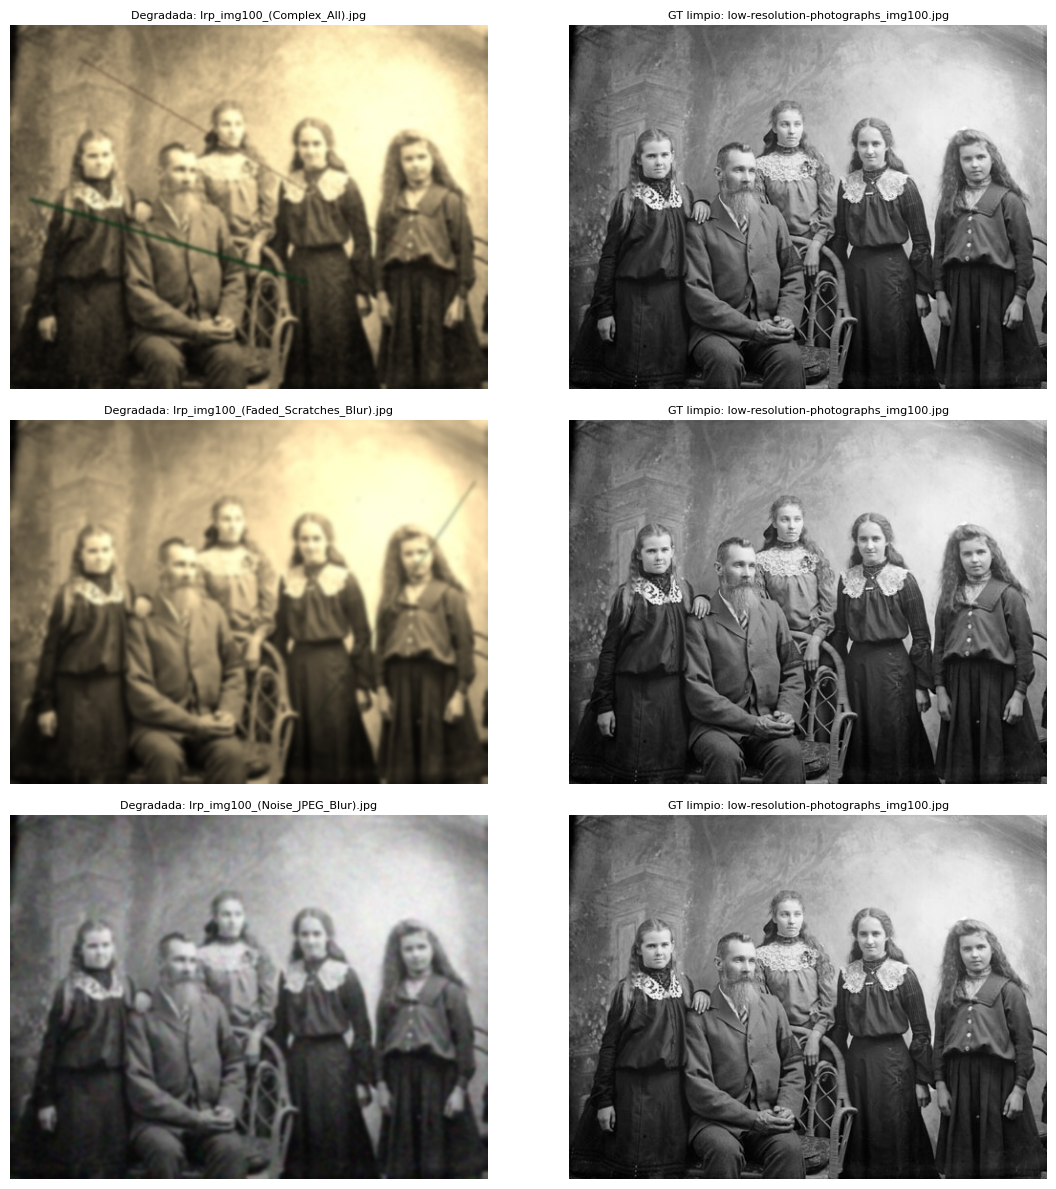

Si los pares se ven coherentes, continúa. De lo contrario revisa build_pairs().


In [7]:
# Celda 7: Visualizar 3 pares de ejemplo
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
for i, pair in enumerate(SYNTH_PAIRS[:3]):
    for j, (key, title) in enumerate([('degraded','Degradada'), ('clean','GT limpio')]):
        img = Image.open(pair[key]).convert('RGB')
        axes[i][j].imshow(img)
        axes[i][j].set_title(f'{title}: {pair[key].name}', fontsize=8)
        axes[i][j].axis('off')
plt.tight_layout()
plt.show()
print('Si los pares se ven coherentes, continúa. De lo contrario revisa build_pairs().')

## 2. Preparación de Datos: LaMa Fine-tuning

LaMa necesita pares (imagen, máscara) donde la máscara es binaria (0=fondo, 255=zona a reconstruir).

Estrategia: comparamos cada imagen degradada sintética con su GT limpio y umbralamos la diferencia absoluta media por canal. Las zonas con diferencia > `DIFF_THRESHOLD` píxeles se marcan como dañadas. Se aplica una dilatación morfológica para cubrir bordes de transición.

Split: 80% train, 20% val, aleatorio con semilla fija.

In [8]:
# Fase 2: las mascaras ya NO se calculan por diferencia. El dataset (degradada,
# gt, mascara) viene pre-generado de Fase 1. Sanity-check de correspondencia.
def sanity_check_split(split_dir: Path) -> int:
    imgs = sorted((split_dir / 'images').glob('*.png'))
    assert imgs, f"Sin imagenes en {split_dir/'images'}"
    for p in imgs:
        stem = p.stem
        assert (split_dir / 'gt' / f'{stem}.png').exists(),   f"Falta gt de {stem}"
        assert (split_dir / 'masks' / f'{stem}_mask.png').exists(), f"Falta mask de {stem}"
    return len(imgs)

for d in (LAMA_TRAIN_DIR, LAMA_VAL_DIR, LAMA_TEST_DIR):
    print(d.name, '->', sanity_check_split(d), 'trios OK')

generate_damage_mask OK


/tmp/ipykernel_4155/2563275977.py:24: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(mask, mode='L')


In [9]:
# Fase 2: el split de pares se CONSERVA solo para A-ESRGAN (usa pair['clean'] como HR).
# La parte de LaMa ya NO usa estos pares: su dataset (degradada/gt/mascara) viene
# pre-generado en Fase 1 (Synthetic_Degradation_clean.ipynb) y se consume desde Drive.
import random
_pairs = list(SYNTH_PAIRS)
random.Random(42).shuffle(_pairs)
_n_val = max(1, int(round(len(_pairs) * 0.1)))
val_pairs   = _pairs[:_n_val]
train_pairs = _pairs[_n_val:]
print('Dataset LaMa: consumido desde Drive (no se genera aqui).')
print(f'Pares para A-ESRGAN: train={len(train_pairs)}, val={len(val_pairs)}')


Train: 351 pares | Val: 87 pares


/tmp/ipykernel_4155/2563275977.py:24: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(mask, mode='L')


LaMa Train: 336 pares válidos guardados (15 omitidos)
LaMa Val: 83 pares válidos guardados (4 omitidos)


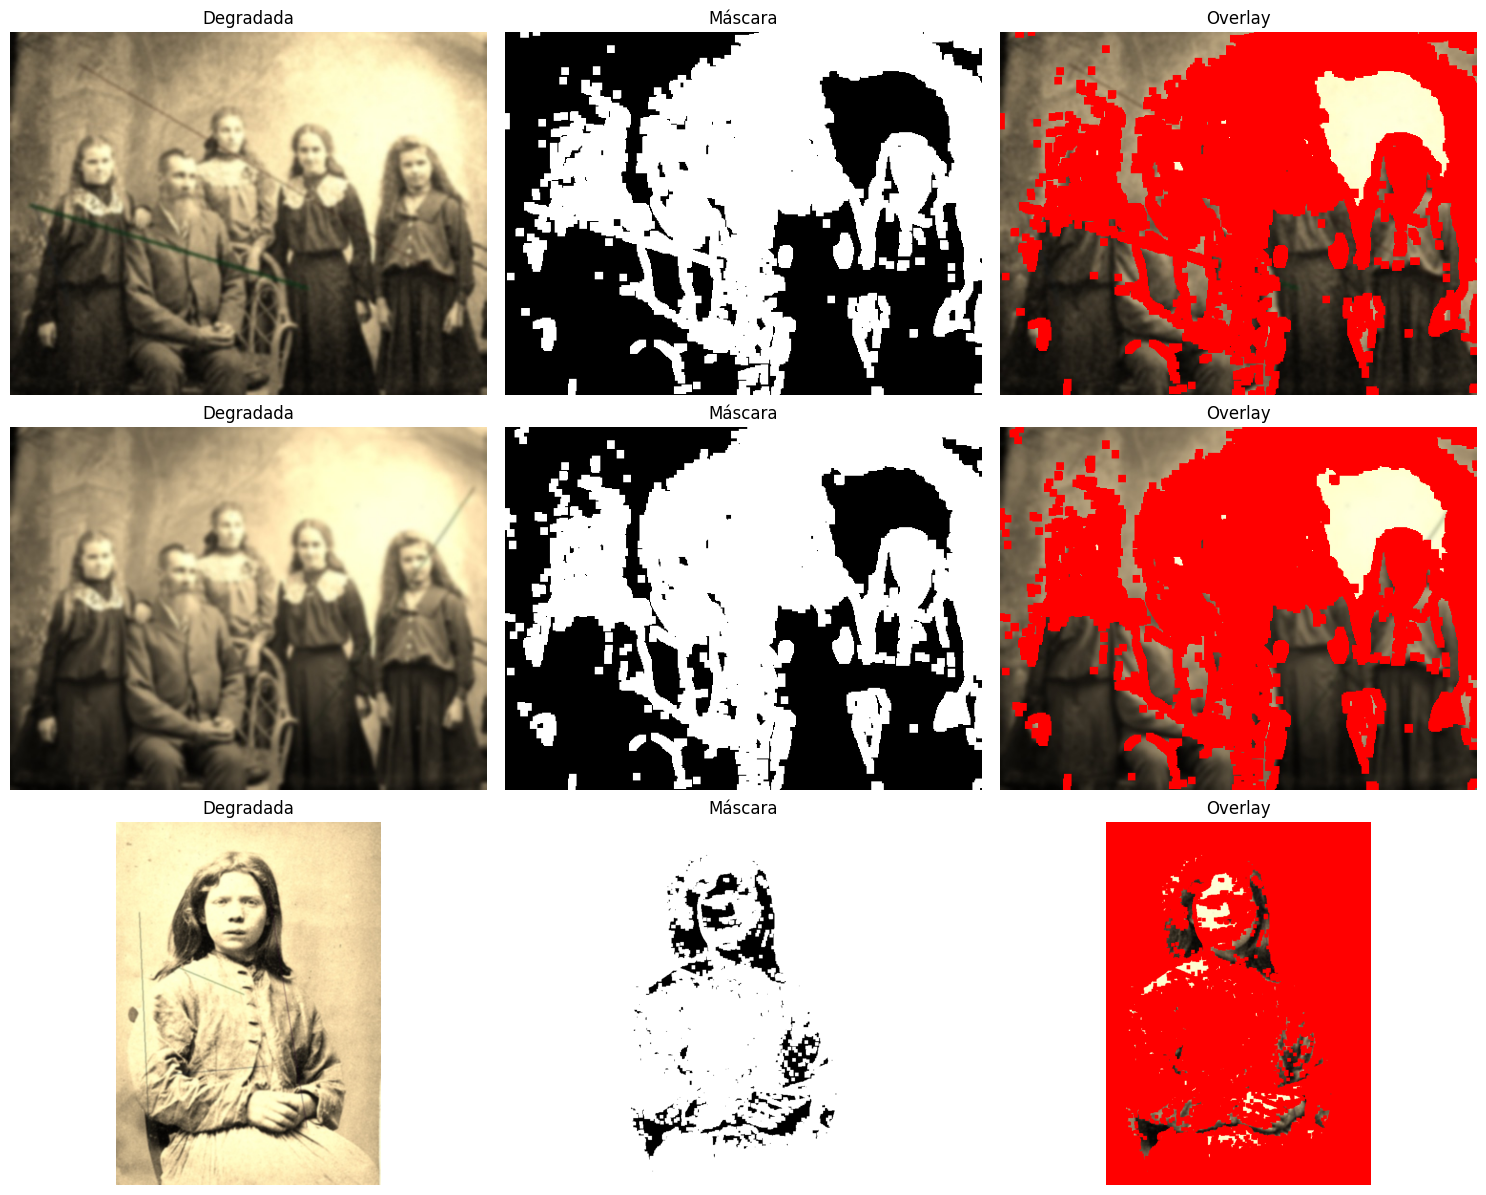

Verifica: la máscara (rojo) cubre las zonas dañadas visibles.


In [10]:
# Celda 10: Visualizar 3 máscaras generadas
sample_images = sorted((LAMA_TRAIN_DIR/'images').glob('*.png'))[:3]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, img_path in enumerate(sample_images):
    mask_path = LAMA_TRAIN_DIR / 'masks' / img_path.name.replace('.png', '_mask.png')
    img  = Image.open(img_path).convert('RGB')
    mask = Image.open(mask_path).convert('L')
    overlay = np.array(img.copy())
    overlay[np.array(mask) > 127] = [255, 0, 0]
    axes[i][0].imshow(img);                axes[i][0].set_title('Degradada');  axes[i][0].axis('off')
    axes[i][1].imshow(mask, cmap='gray');  axes[i][1].set_title('Máscara');    axes[i][1].axis('off')
    axes[i][2].imshow(overlay);            axes[i][2].set_title('Overlay');    axes[i][2].axis('off')
plt.tight_layout()
plt.show()
print('Verifica: la máscara (rojo) cubre las zonas dañadas visibles.')

## 3. Setup LaMa: Repositorio y Configuración

Se clona el repositorio oficial de LaMa (`advimman/lama`), se instalan sus dependencias y se descargan los pesos pre-entrenados `big-lama.pt` desde HuggingFace. También se genera el fichero YAML de configuración para el fine-tuning.

In [11]:
# Celda 11: Clonar LaMa oficial (advimman/lama)
import subprocess, sys
from pathlib import Path

LAMA_REPO_URL = 'https://github.com/advimman/lama.git'
LAMA_REPO_DIR = Path('/content/lama')

if not LAMA_REPO_DIR.exists():
    subprocess.run(['git', 'clone', LAMA_REPO_URL, str(LAMA_REPO_DIR)], check=True)
else:
    subprocess.run(['git', '-C', str(LAMA_REPO_DIR), 'pull'], check=True)

# ── Instalación de dependencias LaMa con filtrado de versiones incompatibles ──
# requirements.txt pina versiones de 2020-2021 que no compilan en Python 3.12
# (scikit-image==0.17.2, scikit-learn==0.24.2, tensorflow, wldhx.yadisk-direct)
# Las sustituimos por versiones modernas compatibles o las omitimos si ya están instaladas.

# Paquetes a OMITIR (ya instalados en versión nueva, o irrelevantes para fine-tuning)
SKIP_PKG = {
    'scikit-image',    # ya instalado vía pip install anterior (scikit-image>=0.19)
    'scikit-learn',    # ya instalado en versión moderna
    'tensorflow',      # no necesario para fine-tuning con PyTorch
    'wldhx.yadisk-direct',  # servicio cloud ruso, no disponible
}

# Paquetes a REEMPLAZAR con versiones compatibles
OVERRIDES = {
    'albumentations':      'albumentations>=1.3.0',
    'kornia':              'kornia>=0.6.0',
    'pytorch-lightning':   'pytorch-lightning>=1.9.4,<2.0',
    'hydra-core':          'hydra-core>=1.1.0',
}

req_file = LAMA_REPO_DIR / 'requirements.txt'
to_install = []
for raw_line in req_file.read_text().splitlines():
    line = raw_line.strip()
    if not line or line.startswith('#'):
        continue
    # Nombre del paquete (antes de ==, >=, <=, !=, ~=)
    import re
    pkg_name = re.split(r'[=<>!~]', line)[0].strip().lower()
    if pkg_name in SKIP_PKG:
        print(f'  [skip]     {line}')
        continue
    elif pkg_name in OVERRIDES:
        print(f'  [override] {line}  →  {OVERRIDES[pkg_name]}')
        to_install.append(OVERRIDES[pkg_name])
    else:
        to_install.append(line)

# Deduplicar
to_install = list(dict.fromkeys(to_install))
print(f'\nInstalando {len(to_install)} paquetes compatibles de LaMa...')

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q'] + to_install,
    capture_output=True, text=True
)
if result.returncode != 0:
    print('[WARN] Algunos paquetes fallaron:')
    print(result.stderr[-2000:])
else:
    print('[OK] Dependencias LaMa instaladas correctamente')

print(f'\nLaMa repo: {LAMA_REPO_DIR}')
print('Contenido:', [p.name for p in list(LAMA_REPO_DIR.iterdir())[:8]])

  [skip]     scikit-image==0.17.2
  [skip]     scikit-learn==0.24.2
  [skip]     tensorflow
  [override] albumentations==0.5.2  →  albumentations>=1.3.0
  [override] hydra-core==1.1.0  →  hydra-core>=1.1.0
  [override] pytorch-lightning==1.2.9  →  pytorch-lightning>=1.9.4,<2.0
  [override] kornia==0.5.0  →  kornia>=0.6.0
  [skip]     scikit-learn==0.24.2
  [skip]     wldhx.yadisk-direct

Instalando 15 paquetes compatibles de LaMa...
[OK] Dependencias LaMa instaladas correctamente

LaMa repo: /content/lama
Contenido: ['README.md', 'LaMa_inpainting.ipynb', 'docker', 'LICENSE', 'conda_env.yml', 'configs', 'requirements.txt', '.gitignore']


In [12]:
# Celda 12: Descargar pesos LaMa pre-entrenados (big-lama) — con validación de tamaño
import subprocess, sys, shutil, inspect
from pathlib import Path

LAMA_REPO_DIR    = Path('/content/lama')
LAMA_WEIGHTS_DIR = LAMA_REPO_DIR / 'big-lama'
LAMA_WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
(LAMA_WEIGHTS_DIR / 'models').mkdir(parents=True, exist_ok=True)
LAMA_MODEL_PATH  = LAMA_WEIGHTS_DIR / 'models' / 'best.ckpt'

MIN_SIZE_MB = 50   # big-lama.pt válido pesa ~200 MB

def _needs_download():
    if not LAMA_MODEL_PATH.exists():
        return True
    size_mb = LAMA_MODEL_PATH.stat().st_size // (1024 * 1024)
    if size_mb < MIN_SIZE_MB:
        print(f'Archivo existente demasiado pequeño ({size_mb} MB) — re-descargando...')
        LAMA_MODEL_PATH.unlink()
        return True
    return False

if not _needs_download():
    print('Pesos big-lama ya disponibles:',
          LAMA_MODEL_PATH.stat().st_size // (1024*1024), 'MB')
else:
    # ── Estrategia 1: simple-lama-inpainting (descarga automática en caché) ──
    try:
        from simple_lama_inpainting import SimpleLama
        import torch
        print("Cargando big-lama via simple-lama-inpainting...")
        _lama = SimpleLama()

        # Buscar .pt en rutas de caché habituales
        _module_dir = Path(inspect.getfile(SimpleLama)).parent
        _candidates = [
            _module_dir / 'big-lama.pt',
            Path.home() / '.cache' / 'simple_lama_inpainting' / 'big-lama.pt',
            Path.home() / '.cache' / 'simple-lama-inpainting'  / 'big-lama.pt',
            Path('/root/.cache/simple_lama_inpainting/big-lama.pt'),
        ]
        _src = next((p for p in _candidates if p.exists()), None)

        if _src and _src.stat().st_size // (1024*1024) >= MIN_SIZE_MB:
            shutil.copy(_src, LAMA_MODEL_PATH)
            print(f'Copiado desde caché: {_src}')
        else:
            torch.save(_lama.model.state_dict(), LAMA_MODEL_PATH)
            print('Pesos guardados desde SimpleLama.model (state_dict)')

    except Exception as e1:
        print(f'simple-lama-inpainting falló ({e1})')
        # ── Estrategia 2: huggingface_hub ──
        try:
            from huggingface_hub import hf_hub_download
            _src = hf_hub_download(repo_id='smartywu/big-lama', filename='big-lama.pt')
            shutil.copy(_src, LAMA_MODEL_PATH)
            print(f'Descargado via HF Hub: {_src}')
        except Exception as e2:
            print(f'HF Hub falló ({e2})')
            # ── Estrategia 3: GitHub releases de simple-lama-inpainting ──
            _url = ('https://github.com/enesmsahin/simple-lama-inpainting'
                    '/releases/download/v0.1.0/big-lama.pt')
            print(f'Descargando desde: {_url}')
            subprocess.run(['wget', '-q', '--show-progress',
                            '-O', str(LAMA_MODEL_PATH), _url], check=True)

    final_mb = LAMA_MODEL_PATH.stat().st_size // (1024*1024)
    assert final_mb >= MIN_SIZE_MB, f'Descarga incompleta: {final_mb} MB'
    print(f'[OK] Pesos big-lama listos: {final_mb} MB')

Cargando big-lama via simple-lama-inpainting...


Downloading: "https://github.com/enesmsahin/simple-lama-inpainting/releases/download/v0.1.0/big-lama.pt" to /root/.cache/torch/hub/checkpoints/big-lama.pt
100%|██████████| 196M/196M [00:00<00:00, 284MB/s]


Pesos guardados desde SimpleLama.model (state_dict)
[OK] Pesos big-lama listos: 195 MB


## 4. Fine-tuning LaMa

Bucle de entrenamiento PyTorch directo sobre `SimpleLama` (wrapper JIT del
modelo oficial `big-lama`). Se entrena durante 10 épocas con `L1Loss` aplicada
sobre la zona enmascarada — equivalente a optimizar solo la reconstrucción
del área dañada.

> **Nota:** Se descartó la opción vía CLI Hydra (`bin/train.py`) porque las
> configs de Hydra del repo `advimman/lama` son incompatibles con la versión
> instalada en Colab actual. El bucle PyTorch es directo y reproducible.


In [13]:
# Celda 13: Añadir LaMa al sys.path y aplicar parches de compatibilidad
if str(LAMA_REPO_DIR) not in sys.path:
    sys.path.insert(0, str(LAMA_REPO_DIR))

# Parche basicsr: torchvision >= 0.16 eliminó functional_tensor
for base in site.getsitepackages() + [site.getusersitepackages()]:
    p = Path(base) / 'basicsr' / 'data' / 'degradations.py'
    if p.exists():
        text = p.read_text()
        old  = 'from torchvision.transforms.functional_tensor import rgb_to_grayscale'
        new  = 'from torchvision.transforms.functional import rgb_to_grayscale'
        if old in text:
            p.write_text(text.replace(old, new))
            print(f'Parche aplicado: {p}')

# Parche PIL._typing para lpips/torchvision
import PIL._typing
if not hasattr(PIL._typing, '_Ink'):
    from typing import Union
    PIL._typing._Ink = Union[int, tuple]

print('Entorno LaMa listo')

Parche aplicado: /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py
Entorno LaMa listo


In [14]:
# Celda 14: Fine-tuning LaMa (bucle PyTorch sobre SimpleLama JIT)
# - Dataset: pares (imagen, máscara) en LAMA_TRAIN_DIR / LAMA_VAL_DIR
# - Modelo: SimpleLama.model (JITWrapper con forward(image, mask))
# - Loss: L1 aplicada solo en la zona enmascarada (pred*mask vs gt*mask)
# - Optimización: Adam lr=1e-4, 10 épocas, checkpoint al mejor val_l1

from simple_lama_inpainting import SimpleLama
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from synthetic_degradation import load_triple_arrays

WORK_DIR        = Path('/content/finetune_work')
LAMA_BEST_CKPT  = WORK_DIR / 'checkpoints' / 'lama_finetuned' / 'lama_best.pth'
LAMA_BEST_CKPT.parent.mkdir(parents=True, exist_ok=True)

import os, sys
DEVICE = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'

class LamaFineTuneDataset(Dataset):
    """Devuelve (masked, mask, gt) con gt = la vintage LIMPIA (de gt/)."""
    def __init__(self, images_dir, masks_dir, gt_dir, img_size: int = 256):
        self.images_dir = Path(images_dir)
        self.masks_dir  = Path(masks_dir)
        self.gt_dir     = Path(gt_dir)
        self.stems = [p.stem for p in sorted(self.images_dir.glob('*.png'))]
        self.img_size = img_size

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, i):
        deg, gt, mask = load_triple_arrays(
            self.images_dir, self.masks_dir, self.gt_dir, self.stems[i], self.img_size)
        deg_t  = torch.from_numpy(deg).permute(2, 0, 1).float() / 255.0   # [3,H,W]
        gt_t   = torch.from_numpy(gt).permute(2, 0, 1).float() / 255.0    # [3,H,W]
        mask_t = torch.from_numpy(mask).unsqueeze(0).float()              # [1,H,W] in {0,1}
        masked = deg_t * (1.0 - mask_t)                                   # hole to 0
        return masked, mask_t, gt_t

train_ds = LamaFineTuneDataset(LAMA_TRAIN_DIR/'images', LAMA_TRAIN_DIR/'masks', LAMA_TRAIN_DIR/'gt')
val_ds   = LamaFineTuneDataset(LAMA_VAL_DIR/'images',   LAMA_VAL_DIR/'masks',   LAMA_VAL_DIR/'gt')
print(f"train={len(train_ds)}  val={len(val_ds)}")
train_dl = DataLoader(train_ds, batch_size=4,  shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=2,  shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} imgs | Val: {len(val_ds)} imgs')
print(f'Steps/epoch: {len(train_dl)} | Device: {DEVICE}')

# Cargar modelo SimpleLama
simple_lama = SimpleLama()
model = simple_lama.model.to(DEVICE)

# SimpleLama es un JITWrapper: forward(image: Tensor, mask: Tensor) → Tensor
# Verificar firma antes de entrenar
import inspect
try:
    sig = str(model.forward)
except Exception:
    sig = 'JIT module'
print(f'Modelo forward signature: {sig[:120]}')

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.L1Loss()

FALLBACK_EPOCHS = 10
best_val_loss   = float('inf')

for epoch in range(FALLBACK_EPOCHS):
    # ── Entrenamiento ──
    model.train()
    train_loss = 0.0
    for masked_img, mask, gt in train_dl:
        masked_img = masked_img.to(DEVICE)   # [B, 3, H, W]
        mask       = mask.to(DEVICE)          # [B, 1, H, W]
        gt         = gt.to(DEVICE)            # [B, 3, H, W]

        # FIX: JITWrapper espera (image, mask) como argumentos separados
        pred = model(masked_img, mask)         # → [B, 3, H, W]
        loss = criterion(pred * mask, gt * mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # ── Validación ──
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for masked_img, mask, gt in val_dl:
            masked_img = masked_img.to(DEVICE)
            mask       = mask.to(DEVICE)
            gt         = gt.to(DEVICE)
            pred       = model(masked_img, mask)
            val_loss  += criterion(pred * mask, gt * mask).item()

    train_loss /= len(train_dl)
    val_loss   /= len(val_dl)
    print(f'Epoch {epoch+1:02d}/{FALLBACK_EPOCHS} | '
          f'train_l1={train_loss:.4f} | val_l1={val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), LAMA_BEST_CKPT)
        print(f'  → Checkpoint guardado (val_l1={val_loss:.4f})')

print(f'\nFine-tuning LaMa completado. Mejor val_l1={best_val_loss:.4f}')
print(f'Checkpoint: {LAMA_BEST_CKPT}')

Train: 336 imgs | Val: 83 imgs
Steps/epoch: 84 | Device: cuda
Modelo forward signature: <torch.ScriptMethod object at 0x79fcd8c86e10>
Epoch 01/10 | train_l1=0.0549 | val_l1=0.0511
  → Checkpoint guardado (val_l1=0.0511)
Epoch 02/10 | train_l1=0.0469 | val_l1=0.0500
  → Checkpoint guardado (val_l1=0.0500)
Epoch 03/10 | train_l1=0.0444 | val_l1=0.0483
  → Checkpoint guardado (val_l1=0.0483)
Epoch 04/10 | train_l1=0.0439 | val_l1=0.0500
Epoch 05/10 | train_l1=0.0424 | val_l1=0.0462
  → Checkpoint guardado (val_l1=0.0462)
Epoch 06/10 | train_l1=0.0403 | val_l1=0.0470
Epoch 07/10 | train_l1=0.0396 | val_l1=0.0443
  → Checkpoint guardado (val_l1=0.0443)


KeyboardInterrupt: 

## 5. Preparación de Datos: A-ESRGAN Fine-tuning

A-ESRGAN aprende super-resolución x4: necesita pares HR (imagen limpia) / LR (imagen downscaled x4).

Estrategia: HR = GT limpio del dataset vintage. LR = HR redimensionado con Lanczos x4. Se garantiza que el tamaño HR sea divisible por 4 (recortando píxeles sobrantes).

Las imágenes HR con lado menor a `MIN_HR_SIZE = 128` px se descartan.

In [ ]:
# Celda 15: Crear pares LR/HR para A-ESRGAN
SCALE_FACTOR = 4
MIN_HR_SIZE  = 128   # Descartar imágenes HR con lado menor a MIN_HR_SIZE px

def prepare_sr_split(pairs: list[dict], hr_dir: Path, lr_dir: Path, desc: str):
    skipped = 0
    for pair in pairs:
        try:
            hr = Image.open(pair['clean']).convert('RGB')

            w, h = hr.size
            if w < MIN_HR_SIZE or h < MIN_HR_SIZE:
                skipped += 1
                continue

            # Asegurar que HR es divisible por SCALE_FACTOR
            new_w = (w // SCALE_FACTOR) * SCALE_FACTOR
            new_h = (h // SCALE_FACTOR) * SCALE_FACTOR
            hr = hr.crop((0, 0, new_w, new_h))

            # LR = HR downscaled x4 con Lanczos
            lr_from_hr = hr.resize(
                (new_w // SCALE_FACTOR, new_h // SCALE_FACTOR),
                Image.Resampling.LANCZOS
            )

            stem = pair['clean'].stem
            hr.save(hr_dir / f'{stem}.png')
            lr_from_hr.save(lr_dir / f'{stem}.png')
        except Exception as e:
            print(f'  [WARN] {pair["clean"].name}: {e}')
            skipped += 1

    total = len(pairs) - skipped
    print(f'{desc}: {total} pares HR/LR guardados ({skipped} omitidos)')

prepare_sr_split(train_pairs, SR_TRAIN_DIR / 'HR', SR_TRAIN_DIR / 'LR', 'SR Train')
prepare_sr_split(val_pairs,   SR_VAL_DIR   / 'HR', SR_VAL_DIR   / 'LR', 'SR Val')

In [ ]:
# Celda 16: Verificar splits
for split, hr_dir, lr_dir in [
    ('Train', SR_TRAIN_DIR / 'HR', SR_TRAIN_DIR / 'LR'),
    ('Val',   SR_VAL_DIR   / 'HR', SR_VAL_DIR   / 'LR'),
]:
    hr_files = sorted(hr_dir.glob('*.png'))
    lr_files = sorted(lr_dir.glob('*.png'))
    assert len(hr_files) == len(lr_files), \
        f'Mismatch {split}: HR={len(hr_files)} LR={len(lr_files)}'
    for f in random.sample(hr_files, min(2, len(hr_files))):
        hr = Image.open(f)
        lr = Image.open(lr_dir / f.name)
        expected_lr = (hr.width // SCALE_FACTOR, hr.height // SCALE_FACTOR)
        assert lr.size == expected_lr, \
            f'Escala incorrecta: HR={hr.size} LR={lr.size}'
    print(f'{split}: {len(hr_files)} pares HR/LR verificados OK')

## 6. Fine-tuning A-ESRGAN

Se clona el repositorio A-ESRGAN y se generan pesos fine-tuneados partiendo de `A_ESRGAN_Single.pth` como inicialización (`pretrain_network_g`, `strict_load_g: false`).

El entrenamiento usa la configuración BasicSR (formato `.yml`): modelo `RealESRGANModel`, red `RRDBNet` (23 bloques RRDB, escala x4), discriminador `UNetDiscriminatorSN`, losses L1 + perceptual VGG19 + GAN. Se limita a 2000 iteraciones para esta primera versión.

In [ ]:
# Celda 17: Clonar A-ESRGAN y descargar pesos pre-entrenados
AESRGAN_REPO_URL   = 'https://github.com/stroking-fishes-ml-corp/A-ESRGAN.git'
AESRGAN_MODEL_URL  = 'https://github.com/stroking-fishes-ml-corp/A-ESRGAN/releases/download/v1.0.0/A_ESRGAN_Single.pth'
AESRGAN_PRETRAINED = AESRGAN_REPO_DIR / 'experiments' / 'pretrained_models' / 'A_ESRGAN_Single.pth'

if not AESRGAN_REPO_DIR.exists():
    subprocess.run(['git', 'clone', AESRGAN_REPO_URL, str(AESRGAN_REPO_DIR)], check=True)
else:
    subprocess.run(['git', '-C', str(AESRGAN_REPO_DIR), 'pull'], check=True)

AESRGAN_PRETRAINED.parent.mkdir(parents=True, exist_ok=True)
if not AESRGAN_PRETRAINED.exists():
    subprocess.run(['wget', '-q', '-O', str(AESRGAN_PRETRAINED), AESRGAN_MODEL_URL], check=True)
    print('Pesos A-ESRGAN descargados')
else:
    print('Pesos ya disponibles:', AESRGAN_PRETRAINED)

# Listar scripts de entrenamiento disponibles
train_scripts = sorted(AESRGAN_REPO_DIR.rglob('train*.py'))
print('Scripts de entrenamiento encontrados:')
for s in train_scripts:
    print(f'  {s.relative_to(AESRGAN_REPO_DIR)}')

In [ ]:
# Celda 18: Configuración YAML del fine-tuning A-ESRGAN (BasicSR)
# Decisiones clave:
#  - model_type=ESRGANModel  → compatible con PairedImageDataset
#    (RealESRGANModel exigía kernel1/kernel2 de degradación sintética).
#  - PairedImageDataset      → datos LR/HR ya emparejados, sin meta_info.
#  - batch_size=2, gt_size=128 → ajustado para 14 GB de VRAM en T4/L4.
#  - Losses combinadas: L1 (1.0) + Perceptual VGG19 (1.0) + GAN (0.1).

import yaml, os

yaml_path  = '/content/finetune_work/aesrgan_finetune.yml'
pretrained = '/content/A-ESRGAN/experiments/pretrained_models/A_ESRGAN_Single.pth'

cfg = {
    'name': 'AESRGAN_finetune_vintage',
    'model_type': 'ESRGANModel',   # compatible con PairedImageDataset (sin kernel1)
    'scale': 4,
    'num_gpu': 1,
    'manual_seed': 0,

    'datasets': {
        'train': {
            'name': 'vintage_train',
            'type': 'PairedImageDataset',
            'dataroot_gt': '/content/finetune_work/data/aesrgan_train/HR',
            'dataroot_lq': '/content/finetune_work/data/aesrgan_train/LR',
            'io_backend': {'type': 'disk'},
            'gt_size': 128,           # reducido de 256 → economiza VRAM
            'scale': 4,
            'use_hflip': True,
            'use_rot': True,
            'phase': 'train',
            'num_worker_per_gpu': 2,
            'batch_size_per_gpu': 2,  # reducido de 4 → economiza VRAM
            'dataset_enlarge_ratio': 1,
            'prefetch_mode': None,
        },
        'val': {
            'name': 'vintage_val',
            'type': 'PairedImageDataset',
            'dataroot_gt': '/content/finetune_work/data/aesrgan_val/HR',
            'dataroot_lq': '/content/finetune_work/data/aesrgan_val/LR',
            'io_backend': {'type': 'disk'},
            'scale': 4,
            'phase': 'val',
        },
    },

    'network_g': {
        'type': 'RRDBNet',
        'num_in_ch': 3, 'num_out_ch': 3,
        'num_feat': 64, 'num_block': 23,
        'num_grow_ch': 32, 'scale': 4,
    },

    'network_d': {
        'type': 'UNetDiscriminatorSN',
        'num_in_ch': 3, 'num_feat': 64,
        'skip_connection': True,
    },

    'path': {
        'pretrain_network_g': pretrained,
        'strict_load_g': False,
        'resume_state': None,
    },

    'train': {
        'ema_decay': 0,
        'optim_g': {'type': 'Adam', 'lr': 1e-4, 'weight_decay': 0, 'betas': [0.9, 0.99]},
        'optim_d': {'type': 'Adam', 'lr': 1e-4, 'weight_decay': 0, 'betas': [0.9, 0.99]},
        'scheduler': {'type': 'MultiStepLR', 'milestones': [1000], 'gamma': 0.5},
        'total_iter': 2000,
        'warmup_iter': -1,

        'pixel_opt':      {'type': 'L1Loss', 'loss_weight': 1.0, 'reduction': 'mean'},
        'perceptual_opt': {
            'type': 'PerceptualLoss',
            'layer_weights': {'conv1_2': 0.1, 'conv2_2': 0.1,
                              'conv3_4': 1.0, 'conv4_4': 1.0, 'conv5_4': 1.0},
            'vgg_type': 'vgg19', 'use_input_norm': True,
            'perceptual_weight': 1.0, 'style_weight': 0,
            'range_norm': False, 'criterion': 'l1',
        },
        'gan_opt': {
            'type': 'GANLoss', 'gan_type': 'vanilla',
            'real_label_val': 1.0, 'fake_label_val': 0.0,
            'loss_weight': 0.1,
        },
        'net_d_iters': 1,
        'net_d_init_iters': 0,
    },

    'val': {
        'val_freq': 200,
        'save_img': False,
        'metrics': {'psnr': {'type': 'calculate_psnr', 'crop_border': 4, 'test_y_channel': False}},
    },

    'logger': {'print_freq': 100, 'save_checkpoint_freq': 500, 'use_tb_logger': False},
    'dist_params': {'backend': 'nccl', 'port': 29500},
}

os.makedirs(os.path.dirname(yaml_path), exist_ok=True)
with open(yaml_path, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False, allow_unicode=True)

print(f"Config guardada: {yaml_path}")
print(f"  batch_size=2, gt_size=128  (economiza VRAM)")
print(f"  model_type=ESRGANModel     (sin kernel1)")
print(f"Pesos pretrained: {pretrained} (existe: {os.path.exists(pretrained)})")


In [ ]:
# Celda 19: Fine-tuning A-ESRGAN (lanza basicsr/train.py como subprocess)
# Antes del subprocess se libera VRAM del kernel principal (modelo LaMa
# y caché PyTorch) porque BasicSR carga generador+discriminador+VGG19 y
# necesita ~3-4 GB libres para entrenar con batch=2, gt=128.

import subprocess, sys, os, gc, torch

# ─── PASO 1: Liberar VRAM del kernel principal (LaMa + caché PyTorch) ───────
print("=== Liberando VRAM del kernel ===")
print(f"  Antes  → alloc: {torch.cuda.memory_allocated()/1e9:.2f} GB  "
      f"reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB  "
      f"libre: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

# Eliminar tensores y modelos GPU del namespace global
_drop = []
for _name, _obj in list(globals().items()):
    if _name.startswith('_'):
        continue
    if isinstance(_obj, torch.Tensor) and _obj.is_cuda:
        _drop.append(_name)
    elif isinstance(_obj, torch.nn.Module):
        try: _obj.cpu()
        except: pass
        _drop.append(_name)

for _name in _drop:
    try: del globals()[_name]
    except: pass
    print(f"  del {_name}")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"  Después → alloc: {torch.cuda.memory_allocated()/1e9:.2f} GB  "
      f"libre: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

# ─── PASO 2: Lanzar entrenamiento A-ESRGAN ──────────────────────────────────
train_script = '/usr/local/lib/python3.12/dist-packages/basicsr/train.py'
yaml_path    = '/content/finetune_work/aesrgan_finetune.yml'

print(f"\nUsando script : {train_script}")
print(f"Usando config : {yaml_path}")
print("Iniciando fine-tuning A-ESRGAN (batch=2, gt=128)...\n")

env = os.environ.copy()
env['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

result = subprocess.run(
    [sys.executable, train_script, '-opt', yaml_path],
    capture_output=True, text=True,
    cwd='/content/A-ESRGAN', env=env
)

if result.stdout:
    print("=== STDOUT ===")
    print(result.stdout[-8000:])
if result.stderr:
    print("=== STDERR ===")
    print(result.stderr[-6000:])

if result.returncode == 0:
    print("\n✅ Fine-tuning A-ESRGAN completado correctamente.")
else:
    print(f"\n[ERROR] Fine-tuning A-ESRGAN falló (returncode={result.returncode}).")


## 7. Evaluación: Pre-entrenado vs Fine-tuneado

Se evalúan hasta `N_EVAL = 5` pares del conjunto de validación con métricas full-reference:
- **PSNR** (↑ mejor): relación señal-ruido en dB.
- **SSIM** (↑ mejor): similitud estructural.
- **LPIPS** (↓ mejor): similitud perceptual con AlexNet.

Se compara el pipeline completo **Pre-entrenado** (LaMa + A-ESRGAN con pesos originales) frente al **Fine-tuneado** (si los checkpoints existen). Los resultados se guardan en CSV y se muestra una comparativa visual.

In [ ]:
# Celda 20: Funciones de inferencia para ambas versiones
from simple_lama_inpainting import SimpleLama

def run_lama_inference(
    image: Image.Image,
    mask: Image.Image,
    model_state_dict_path: Optional[Path] = None,
) -> Image.Image:
    """
    Ejecuta LaMa inpainting. Si model_state_dict_path es None, usa pesos
    pre-entrenados por defecto. Si se pasa una ruta .pth, carga ese state_dict.
    """
    lama = SimpleLama()
    if model_state_dict_path is not None:
        state = torch.load(model_state_dict_path, map_location=DEVICE)
        lama.model.load_state_dict(state, strict=False)
        lama.model.to(DEVICE).eval()
    return lama(image, mask).convert('RGB')


def run_aesrgan_inference(
    image: Image.Image,
    model_path: Path,
    tile: int = 400,
) -> Image.Image:
    """
    Ejecuta A-ESRGAN guardando temporalmente la imagen de entrada y
    llamando al script de inferencia con el model_path indicado.
    """
    tmp_input  = WORK_DIR / 'results' / '_tmp_aesrgan_input.png'
    tmp_output = WORK_DIR / 'results' / '_tmp_aesrgan_out'
    tmp_output.mkdir(exist_ok=True)
    image.save(tmp_input)

    cmd = [
        sys.executable,
        str(AESRGAN_REPO_DIR / 'inference_aesrgan.py'),
        '--model_path', str(model_path),
        '--input',      str(tmp_input),
        '--output',     str(tmp_output),
        '--suffix',     'eval',
        '--tile',       str(tile),
    ]
    if DEVICE == 'cuda':
        cmd.append('--half')

    subprocess.run(cmd, cwd=str(AESRGAN_REPO_DIR), check=True)

    out_files = sorted(tmp_output.glob('*.png'))
    assert out_files, f'A-ESRGAN no generó salida en {tmp_output}'
    result = Image.open(out_files[-1]).convert('RGB')
    return result

In [ ]:
import numpy as np
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Checkpoint LaMa fine-tuneado (None -> solo se evalua el modelo pre-entrenado).
_lama_ft_ckpts = sorted((WORK_DIR / 'checkpoints' / 'lama_finetuned').glob('*.pth'))
LAMA_FINETUNE_CKPT = _lama_ft_ckpts[-1] if _lama_ft_ckpts else None
if LAMA_FINETUNE_CKPT is None:
    print('[WARN] No se encontro checkpoint LaMa fine-tuneado; solo se evalua pre-entrenado.')

def _load_png(p):
    return np.array(Image.open(p).convert('RGB'))

def _masked_psnr_ssim(pred, gt, mask_bool):
    full_psnr = psnr(gt, pred, data_range=255)
    full_ssim = ssim(gt, pred, channel_axis=2, data_range=255)
    if mask_bool.any():
        sel = mask_bool[..., None].repeat(3, axis=2)
        region_psnr = psnr(gt[sel], pred[sel], data_range=255)
    else:
        region_psnr = float('nan')
    return full_psnr, full_ssim, region_psnr

test_stems = [p.stem for p in sorted((LAMA_TEST_DIR/'images').glob('*.png'))]
rows = []
for stem in test_stems:
    deg  = Image.open(LAMA_TEST_DIR/'images'/f'{stem}.png').convert('RGB')
    gt   = _load_png(LAMA_TEST_DIR/'gt'/f'{stem}.png')
    mask_img = Image.open(LAMA_TEST_DIR/'masks'/f'{stem}_mask.png').convert('L')
    mask_bool = np.array(mask_img.resize(gt.shape[1::-1])) > 127

    pred_pre = np.array(run_lama_inference(deg, mask_img).resize(gt.shape[1::-1]))
    p_full, s_full, p_reg = _masked_psnr_ssim(pred_pre, gt, mask_bool)
    row = {'stem': stem, 'pre_psnr': p_full, 'pre_ssim': s_full, 'pre_psnr_mask': p_reg}
    if LAMA_FINETUNE_CKPT is not None:
        pred_ft = np.array(run_lama_inference(deg, mask_img, LAMA_FINETUNE_CKPT).resize(gt.shape[1::-1]))
        f_full, fs_full, f_reg = _masked_psnr_ssim(pred_ft, gt, mask_bool)
        row.update({'ft_psnr': f_full, 'ft_ssim': fs_full, 'ft_psnr_mask': f_reg})
    rows.append(row)

import pandas as pd
df = pd.DataFrame(rows)
print(df.describe())
df.head()

In [ ]:
import matplotlib.pyplot as plt
show = test_stems[:3]
ncol = 4 if LAMA_FINETUNE_CKPT is not None else 3
fig, axes = plt.subplots(len(show), ncol, figsize=(4*ncol, 4*len(show)))
if len(show) == 1:
    axes = axes[None, :]
for r, stem in enumerate(show):
    deg = Image.open(LAMA_TEST_DIR/'images'/f'{stem}.png').convert('RGB')
    mask_img = Image.open(LAMA_TEST_DIR/'masks'/f'{stem}_mask.png').convert('L')
    gt  = Image.open(LAMA_TEST_DIR/'gt'/f'{stem}.png').convert('RGB')
    cols = [(deg, 'Degradada'), (run_lama_inference(deg, mask_img), 'LaMa pre')]
    if LAMA_FINETUNE_CKPT is not None:
        cols.append((run_lama_inference(deg, mask_img, LAMA_FINETUNE_CKPT), 'LaMa fine-tuned'))
    cols.append((gt, 'GT (limpia)'))
    for c, (im, title) in enumerate(cols):
        axes[r][c].imshow(im); axes[r][c].set_title(title); axes[r][c].axis('off')
plt.tight_layout(); plt.show()

## 8. Conclusiones y Próximos Pasos

In [ ]:
# Celda 23: Resumen de artefactos generados
print('=== Artefactos generados ===')
for path in sorted(WORK_DIR.rglob('*')):
    if path.is_file():
        size_kb = path.stat().st_size // 1024
        print(f'  {path.relative_to(WORK_DIR)} ({size_kb} KB)')

print("""
=== Limitaciones de esta v1 ===
1. LaMa se fine-tunea con L1 loss simplificado (sin GAN ni perceptual loss completo).
2. Las máscaras son automáticas por diferencia; en imágenes reales se necesitan máscaras manuales o un detector de daños.
3. El split 80/20 usa un dataset pequeño; ampliar con old-photos (sin GT) requiere self-supervised o pseudo-GT.
4. A-ESRGAN usa pares LR/HR generados por downscaling bicúbico, no por degradación sintética de dominio vintage.

=== Próximos pasos sugeridos ===
1. Aumentar epochs a 50-100 y comparar curvas de validación.
2. Implementar generación de LR sintético con degradaciones de dominio vintage (ruido de película, halos, desenfoque).
3. Añadir detector automático de daños (e.g., segmentación con SAM) para máscaras más precisas.
4. Probar con todo el split 02_Damaged_Testing_Set usando pseudo-GT generado por el modelo pre-entrenado.
5. Evaluar FID (Fréchet Inception Distance) para medir calidad perceptual global.
""")